In [1]:
#1. Data Preparation
from google.colab import files
uploaded = files.upload()

Saving q2_customers.csv to q2_customers.csv


**In K-Means clustering, scaling is essential because the algorithm is based on distance calculations. Features with larger values can dominate the clustering process if not scaled properly. StandardScaler is used to bring all features to the same scale, ensuring fair contribution from each variable.**

In [2]:
import pandas as pd

df2 = pd.read_csv('q2_customers.csv')

In [3]:
df2.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df2)

#2. Choosing K — Elbow Method
**The Elbow Method is used to determine the optimal number of clusters in K-Means clustering. It involves plotting the Within-Cluster Sum of Squares (WCSS) for different values of K and identifying the point where the rate of decrease sharply changes, forming an “elbow”.**

In [5]:
#1. Computing WCSS

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

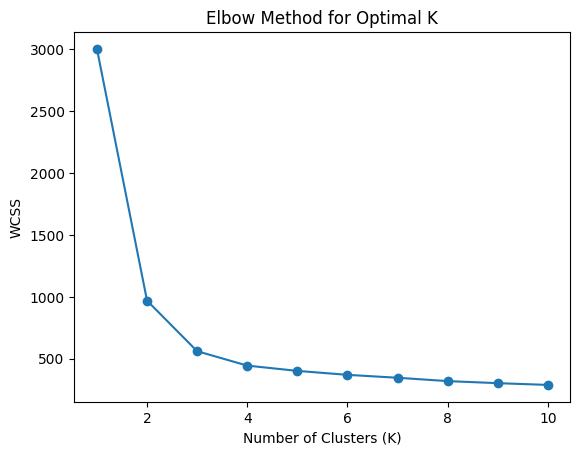

In [6]:
#2. Ploting Elbow Graph

import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

**From the elbow plot, the optimal number of clusters is K = 3, as there is a sharp decrease in WCSS up to K = 3, after which the rate of decrease slows significantly. This indicates that adding more clusters beyond this point does not provide substantial improvement in clustering performance.**

#3. K-Means Clustering
**K-Means clustering is applied using the optimal number of clusters (K = 3). Each customer is assigned to a cluster, and cluster centroids are analysed to understand the characteristics of different customer segments.**

In [7]:
#1. Fit K-Means

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(scaled_data)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [8]:
#2. Adding Cluster Column

df2['cluster'] = kmeans.labels_

df2.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [9]:
#3. Cluster Centroids

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df2.drop('cluster', axis=1).columns
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


**Based on the cluster centroids: *Cluster 0* represents customers with moderate spending and average visit frequency. *Cluster 1* represents high-value customers who spend more, visit frequently, and purchase a larger variety of products. *Cluster 2* represents low-engagement customers with lower spending, fewer visits, and smaller basket sizes. These clusters help the business target customers with personalized marketing strategies.**

#4. Dimensionality Reduction with PCA
**Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset while preserving as much variance as possible. It transforms the original features into a new set of components, where the first component captures the maximum variance and the second captures the next highest variance.**

In [11]:
#1. Applying PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [12]:
#2. Explained Variance Ratio

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [13]:
#3. Feature Loadings

loadings = pd.DataFrame(
    pca.components_,
    columns=df2.drop('cluster', axis=1).columns,
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


The explained variance ratio indicates that PC1 captures approximately 83.6% of the total variance, while PC2 captures about 5.6%. This shows that most of the information in the dataset is represented by the first principal component.

Based on the feature loadings:  
PC1 is strongly influenced by features such as annual spend, basket size, number of categories purchased, and age, indicating that it represents overall customer value and spending behaviour.  

PC2 is primarily influenced by days since last visit, suggesting that it captures customer recency and engagement level. Thus, PCA effectively reduces the dataset into key dimensions representing customer value and recency

#5. Cluster Visualisation
**Cluster visualisation is used to represent the grouped data in a simplified and interpretable form. Since the dataset has multiple dimensions, Principal Component Analysis (PCA) is used to reduce it to two components (PC1 and PC2), making it possible to plot the data on a 2D graph. By visualising clusters, we can better understand how customers are grouped and assess how well the clustering algorithm has separated different customer segments.**

In [14]:
pca_data

array([[-3.33081792e-01,  1.09378870e-01],
       [-2.25536231e+00,  4.84578550e-02],
       [-9.29045396e-02, -6.79256763e-01],
       [-2.01759810e+00, -3.08845027e-01],
       [-2.91776201e+00,  5.29368480e-01],
       [-1.29515999e-02,  1.17552126e-02],
       [-6.77848789e-01,  2.27275875e-01],
       [-2.80006339e+00,  1.84216895e-01],
       [-2.25192489e+00,  1.23595793e-01],
       [-1.17949563e+00, -3.88652391e-01],
       [-2.73462837e+00,  8.25499457e-02],
       [ 2.80783253e+00, -9.74414056e-01],
       [-2.78470600e-01,  6.78853301e-02],
       [-2.21616652e+00, -1.22274577e-01],
       [-1.16070890e+00, -2.20959880e-01],
       [-6.08070958e-01, -5.90949189e-01],
       [-1.01525536e-01, -1.20437405e-01],
       [-2.44913803e+00,  4.04624697e-01],
       [ 3.89251460e+00,  8.62713324e-01],
       [ 3.73185324e-02, -6.90993678e-01],
       [-3.86024997e-01, -1.28703820e-01],
       [-2.66633765e-01, -7.77045638e-01],
       [ 1.64638196e+00, -6.37499848e-01],
       [-7.

In [15]:
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

pca_df['cluster'] = df2['cluster']

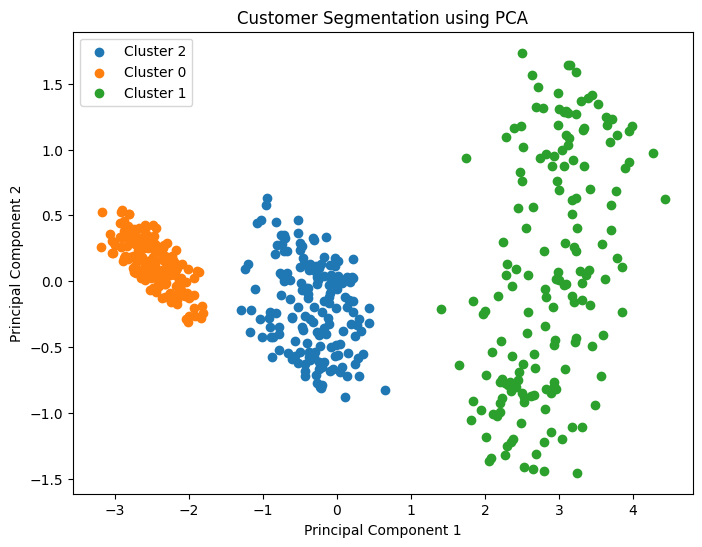

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.title('Customer Segmentation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.show()

**The PCA scatter plot visualises customer clusters in two dimensions. Each point represents a customer, and colours indicate different clusters. The plot shows a reasonable separation between clusters, indicating that the K-Means algorithm has successfully grouped customers based on similar characteristics. This visualisation helps in understanding customer segmentation more intuitively.**